--- Workflow A: The Crime (Leakage) ---
Workflow A (Leaky) Test R^2: 0.222

--- Workflow B: The Audit (No Leakage) ---
Workflow B (non-leaky) Test R^2: -0.851


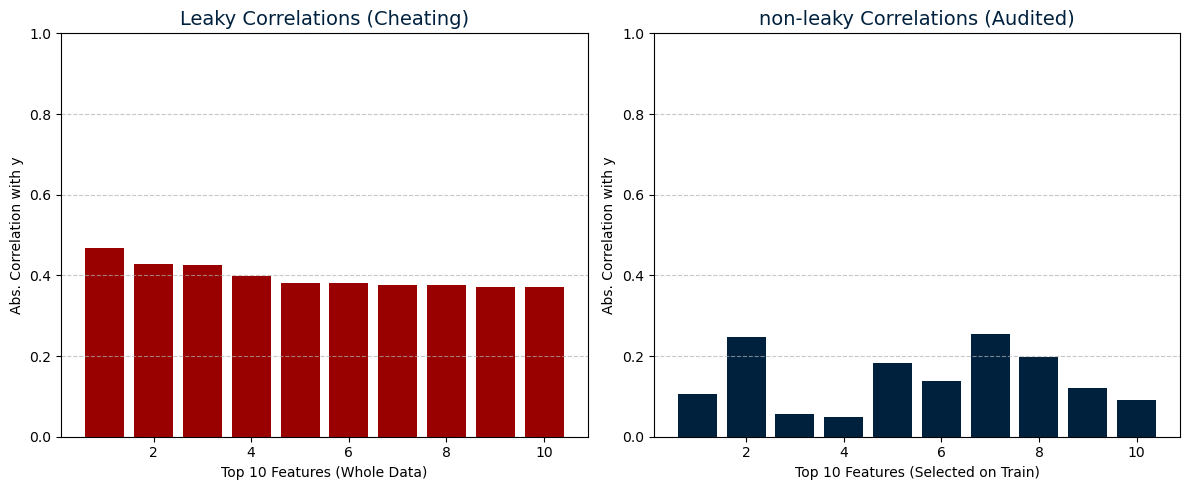


VERDICT:
Workflow A is a scientific crime because information from the test set
labels leaked into the feature selection step. By choosing features
that correlate with the labels across the entire dataset, we found
spurious patterns that happen to exist in the test set by chance.
Workflow B shows that when selection is properly isolated, these
patterns disappear on unseen data.


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Feb 10 13:42:38 2026

@author: sned
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# DTU Colors for plotting
DTU_RED = '#990000'
DTU_NAVY = '#00213E'

def info_leakage_audit():
    '''
    Simulating pure noise to catch Data Leakage.
    '''
    np.random.seed(42)
    N, M = 50, 1000
    # Create pure random noise
    X = np.random.randn(N, M)
    y = np.random.randn(N)

    print('--- Workflow A: The Crime (Leakage) ---')
    # 1. Standardize the WHOLE dataset (X)
    scaler_a = StandardScaler()
    X_scaled_all = scaler_a.fit_transform(X)
    
    # 2. Calculate absolute correlation between each feature and y (using ALL data)
    all_corrs = np.array([np.abs(np.corrcoef(X_scaled_all[:, i], y)[0, 1]) for i in range(M)])
    
    # 3. Select top 10 features
    top_indices_a = np.argsort(all_corrs)[-10:]
    corrs_a = np.sort(all_corrs[top_indices_a])[::-1]
    
    # 4. Create selected dataset and split
    X_selected_a = X_scaled_all[:, top_indices_a]
    X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
        X_selected_a, y, test_size=0.5, random_state=42
    )
    
    # 5. Fit and Score
    model_a = LinearRegression().fit(X_train_a, y_train_a)
    r2_a = model_a.score(X_test_a, y_test_a)
    print(f'Workflow A (Leaky) Test R^2: {r2_a:.3f}')

    print('\n--- Workflow B: The Audit (No Leakage) ---')
    # 1. Split FIRST
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.5, random_state=42
    )
    
    # 2. Standardize Training ONLY, then apply to Test
    scaler_b = StandardScaler().fit(X_train_raw)
    X_train_s = scaler_b.transform(X_train_raw)
    X_test_s = scaler_b.transform(X_test_raw)
    
    # 3. Calculate correlation using Training data ONLY
    train_corrs = np.array([np.abs(np.corrcoef(X_train_s[:, i], y_train)[0, 1]) for i in range(M)])
    
    # 4. Select top 10 features based on training correlations
    top_indices_b = np.argsort(train_corrs)[-10:]
    corrs_b_train = np.sort(train_corrs[top_indices_b])[::-1]
    
    # 5. Subsets
    X_train_sel = X_train_s[:, top_indices_b]
    X_test_sel = X_test_s[:, top_indices_b]
    
    # 6. Fit and Score
    model_b = LinearRegression().fit(X_train_sel, y_train)
    r2_b = model_b.score(X_test_sel, y_test)
    print(f'Workflow B (non-leaky) Test R^2: {r2_b:.3f}')

    # --- VISUALIZATION OF THE EVIDENCE ---
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(range(1, 11), corrs_a, color=DTU_RED)
    plt.title('Leaky Correlations (Cheating)', color=DTU_NAVY, fontsize=14)
    plt.ylabel('Abs. Correlation with y')
    plt.xlabel('Top 10 Features (Whole Data)')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    # Note: We plot the correlations of these features on the TEST set for Workflow B
    # to show they don't actually hold up.
    test_corrs_b = np.array([np.abs(np.corrcoef(X_test_sel[:, i], y_test)[0, 1]) for i in range(10)])
    plt.bar(range(1, 11), test_corrs_b, color=DTU_NAVY)
    plt.title('non-leaky Correlations (Audited)', color=DTU_NAVY, fontsize=14)
    plt.ylabel('Abs. Correlation with y')
    plt.xlabel('Top 10 Features (Selected on Train)')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    print('\nVERDICT:')
    print('Workflow A is a scientific crime because information from the test set')
    print('labels leaked into the feature selection step. By choosing features')
    print('that correlate with the labels across the entire dataset, we found')
    print('spurious patterns that happen to exist in the test set by chance.')
    print('Workflow B shows that when selection is properly isolated, these')
    print('patterns disappear on unseen data.')

if __name__ == "__main__":
    info_leakage_audit()

--- Auditing Model Path ---
Lambda Min: 46.42 (Error: 0.4251)
Lambda 1-SE: 464.16 (Error: 0.4316)


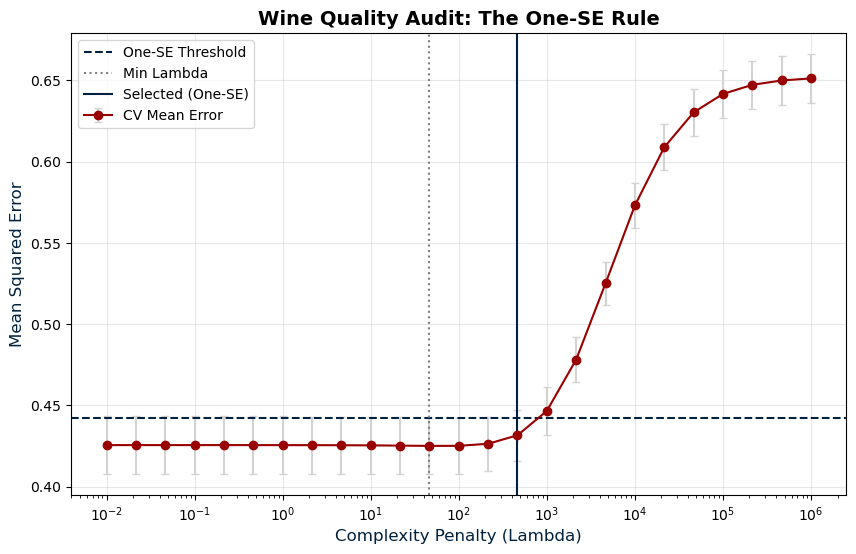


VERDICT:
The auditor selects lambda = 464.16.
While its error is slightly higher than the minimum, it is within
one standard error, meaning the difference is likely noise.
The larger lambda results in a more parsimonious, robust model.


In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Feb 10 15:31:27 2026

@author: sned
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# DTU Colors
DTU_RED = '#990000'
DTU_NAVY = '#00213E'

def wine_audit_one_se_solution():
    '''
    Full solution for Ridge CV and the One-SE Rule.
    '''
    # Load Wine Quality dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    try:
        df = pd.read_csv(url, sep=';')
    except:
        print('Error loading data. Please check internet connection.')
        return

    X = df.drop('quality', axis=1).values
    y = df['quality'].values

    # Scaling is essential for Ridge
    X = StandardScaler().fit_transform(X)

    lambdas = np.logspace(-2, 6, 25)
    K = 10
    kf = KFold(n_splits=K, shuffle=True, random_state=42)
    
    cv_means = []
    cv_ses = []

    print('--- Auditing Model Path ---')
    
    for l in lambdas:
        fold_errors = []
        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            
            model = Ridge(alpha=l).fit(X_tr, y_tr)
            preds = model.predict(X_val)
            fold_errors.append(mean_squared_error(y_val, preds))
        
        cv_means.append(np.mean(fold_errors))
        cv_ses.append(np.std(fold_errors) / np.sqrt(K))

    cv_means = np.array(cv_means)
    cv_ses = np.array(cv_ses)

    # 1. Find lambda_min
    idx_min = np.argmin(cv_means)
    l_min = lambdas[idx_min]
    err_min = cv_means[idx_min]
    se_min = cv_ses[idx_min]

    # 2. Apply One-SE Rule
    threshold = err_min + se_min
    # We want the largest lambda (simplest model) that is below the threshold
    # Note: For Ridge, larger alpha = simpler model
    possible_lambdas_idx = np.where(cv_means <= threshold)[0]
    idx_1se = np.max(possible_lambdas_idx)
    l_1se = lambdas[idx_1se]

    print(f'Lambda Min: {l_min:.2f} (Error: {err_min:.4f})')
    print(f'Lambda 1-SE: {l_1se:.2f} (Error: {cv_means[idx_1se]:.4f})')

    # --- VISUALIZATION ---
    plt.figure(figsize=(10, 6))
    plt.errorbar(lambdas, cv_means, yerr=cv_ses, fmt='o-', 
                 color=DTU_RED, ecolor='lightgray', capsize=3, label='CV Mean Error')
    
    plt.axhline(threshold, color=DTU_NAVY, linestyle='--', label='One-SE Threshold')
    plt.axvline(l_min, color='gray', linestyle=':', label='Min Lambda')
    plt.axvline(l_1se, color=DTU_NAVY, linestyle='-', label='Selected (One-SE)')

    plt.xscale('log')
    plt.xlabel('Complexity Penalty (Lambda)', color=DTU_NAVY, fontsize=12)
    plt.ylabel('Mean Squared Error', color=DTU_NAVY, fontsize=12)
    plt.title('Wine Quality Audit: The One-SE Rule', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print('\nVERDICT:')
    print(f'The auditor selects lambda = {l_1se:.2f}.')
    print('While its error is slightly higher than the minimum, it is within')
    print('one standard error, meaning the difference is likely noise.')
    print('The larger lambda results in a more parsimonious, robust model.')

if __name__ == '__main__':
    wine_audit_one_se_solution()

--- Auditing KNN Complexity ---
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269


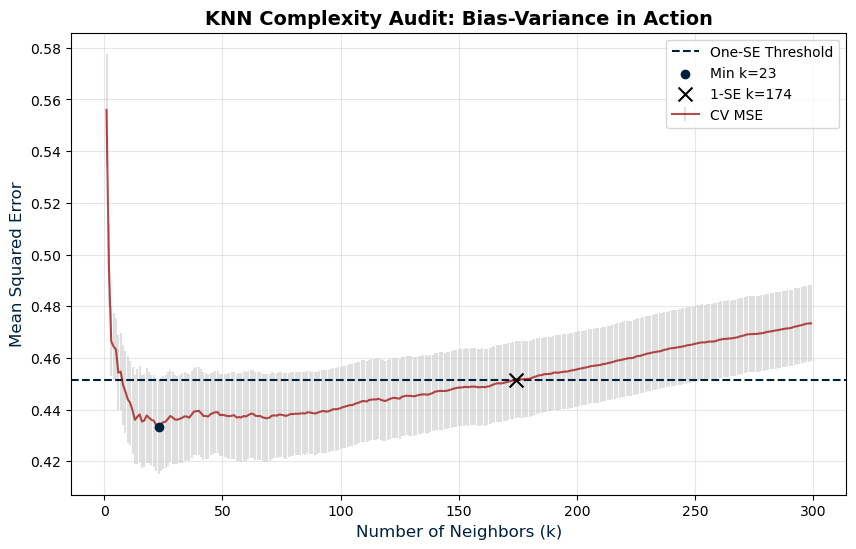


VERDICT:
The auditor chooses k = 174.
Small k leads to high-variance "jagged" predictions.
By choosing the larger k within the SE threshold, we prefer
a smoother, more robust model that generalizes better.


In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Feb 10 15:53:39 2026

@author: sned
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# DTU Colors
DTU_RED = '#990000'
DTU_NAVY = '#00213E'

def knn_complexity_audit_solution():
    '''
    Full solution for KNN complexity audit and One-SE Rule.
    '''
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    df = pd.read_csv(url, sep=';')
    X = StandardScaler().fit_transform(df.drop('quality', axis=1).values)
    y = df['quality'].values

    k_values = np.arange(1, 300)
    K_folds = 10
    kf = KFold(n_splits=K_folds, shuffle=True, random_state=42)
    
    cv_means = []
    cv_ses = []

    print('--- Auditing KNN Complexity ---')

    for k in k_values:
        fold_errors = []
        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            
            model = KNeighborsRegressor(n_neighbors=k).fit(X_tr, y_tr)
            preds = model.predict(X_val)
            fold_errors.append(mean_squared_error(y_val, preds))
        
        cv_means.append(np.mean(fold_errors))
        cv_ses.append(np.std(fold_errors) / np.sqrt(K_folds))
        
        print(k)

    cv_means = np.array(cv_means)
    cv_ses = np.array(cv_ses)

    # 1. Find best k (minimum error)
    idx_min = np.argmin(cv_means)
    k_min = k_values[idx_min]
    err_min = cv_means[idx_min]
    
    # 2. Apply One-SE Rule
    threshold = err_min + cv_ses[idx_min]
    # For KNN, LARGER k means a simpler model (more averaging)
    # So we look for the largest k that is still under the threshold
    possible_k_idx = np.where(cv_means <= threshold)[0]
    idx_1se = np.max(possible_k_idx)
    k_1se = k_values[idx_1se]

    print(f'Optimal k (Min Error): {k_min}')
    print(f'Audited k (One-SE Rule): {k_1se}')

    # --- VISUALIZATION ---
    plt.figure(figsize=(10, 6))
    plt.errorbar(k_values, cv_means, yerr=cv_ses, fmt='-', 
                 color=DTU_RED, ecolor='lightgray', alpha=0.7, label='CV MSE')
    
    plt.axhline(threshold, color=DTU_NAVY, linestyle='--', label='One-SE Threshold')
    plt.scatter(k_min, err_min, color=DTU_NAVY, zorder=5, label=f'Min k={k_min}')
    plt.scatter(k_1se, cv_means[idx_1se], color='black', marker='x', s=100, zorder=5, label=f'1-SE k={k_1se}')

    plt.xlabel('Number of Neighbors (k)', color=DTU_NAVY, fontsize=12)
    plt.ylabel('Mean Squared Error', color=DTU_NAVY, fontsize=12)
    plt.title('KNN Complexity Audit: Bias-Variance in Action', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print('\nVERDICT:')
    print(f'The auditor chooses k = {k_1se}.')
    print('Small k leads to high-variance "jagged" predictions.')
    print('By choosing the larger k within the SE threshold, we prefer')
    print('a smoother, more robust model that generalizes better.')

if __name__ == '__main__':
    knn_complexity_audit_solution()

--- Running Exercise 2.3: AIC vs BIC ---
Optimal model size (AIC): 49
Optimal model size (BIC): 5


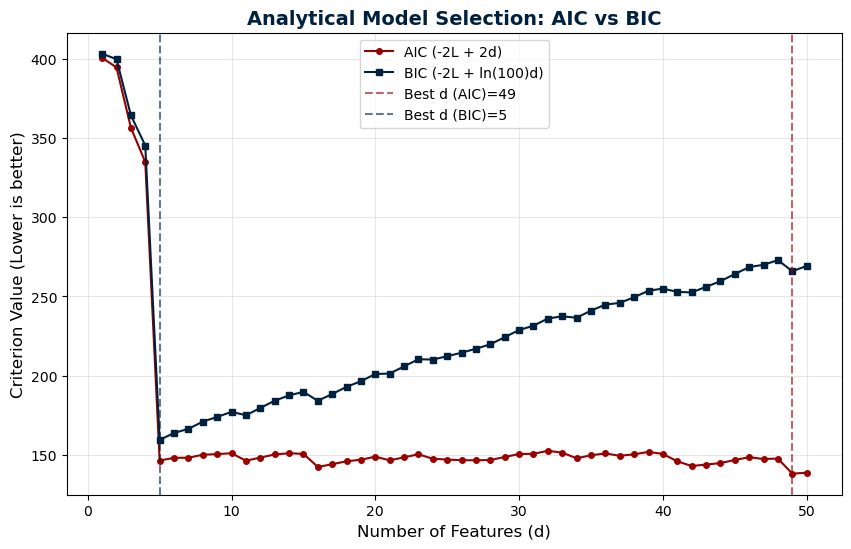


VERDICT:
BIC uses a heavier penalty (ln(N) vs 2). Because N=100, ln(N) is approx 4.6,
making BIC a stricter auditor that favors simpler models than AIC.


In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Feb 10 16:14:45 2026

@author: sned
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# DTU Aesthetics
DTU_RED = '#990000'
DTU_NAVY = '#00213E'

def exercise_2_3_analytical_guards_sol():
    '''
    Full solution for AIC vs BIC comparison.
    '''
    np.random.seed(42)
    N = 100
    M = 50
    X = np.random.randn(N, M)
    # Only the first 5 features contain signal, the rest are noise
    y = X[:, :5] @ np.array([1, 2, 3, 4, 5]) + np.random.randn(N) * 2

    aics = []
    bics = []
    d_values = np.arange(1, M + 1)

    print('--- Running Exercise 2.3: AIC vs BIC ---')

    for d in d_values:
        # 1. Fit OLS using first 'd' features
        X_sub = X[:, :d]
        model = LinearRegression().fit(X_sub, y)
        preds = model.predict(X_sub)
        
        # 2. Residual Sum of Squares
        rss = np.sum((y - preds)**2)
        
        # 3. Log-Likelihood term (assuming Gaussian noise)
        # -2 * logL is proportional to N * ln(RSS/N)
        logL_penalty = N * np.log(rss / N)
        
        # 4. AIC = -2*logL + 2*d
        aics.append(logL_penalty + 2 * d)
        
        # 5. BIC = -2*logL + ln(N)*d
        bics.append(logL_penalty + np.log(N) * d)

    aics = np.array(aics)
    bics = np.array(bics)
    
    # Identify optimal points
    d_aic = d_values[np.argmin(aics)]
    d_bic = d_values[np.argmin(bics)]
    
    print(f'Optimal model size (AIC): {d_aic}')
    print(f'Optimal model size (BIC): {d_bic}')

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(d_values, aics, 'o-', color=DTU_RED, label='AIC (-2L + 2d)', markersize=4)
    plt.plot(d_values, bics, 's-', color=DTU_NAVY, label=f'BIC (-2L + ln({N})d)', markersize=4)
    
    # Highlight minimums
    plt.axvline(d_aic, color=DTU_RED, linestyle='--', alpha=0.6, label=f'Best d (AIC)={d_aic}')
    plt.axvline(d_bic, color=DTU_NAVY, linestyle='--', alpha=0.6, label=f'Best d (BIC)={d_bic}')
    
    plt.title('Analytical Model Selection: AIC vs BIC', color=DTU_NAVY, fontweight='bold', fontsize=14)
    plt.xlabel('Number of Features (d)', fontsize=12)
    plt.ylabel('Criterion Value (Lower is better)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print('\nVERDICT:')
    print('BIC uses a heavier penalty (ln(N) vs 2). Because N=100, ln(N) is approx 4.6,')
    print('making BIC a stricter auditor that favors simpler models than AIC.')

if __name__ == '__main__':
    exercise_2_3_analytical_guards_sol()

--- Starting Ridge Bootstrap Audit (B=1000, alpha=1.0) ---


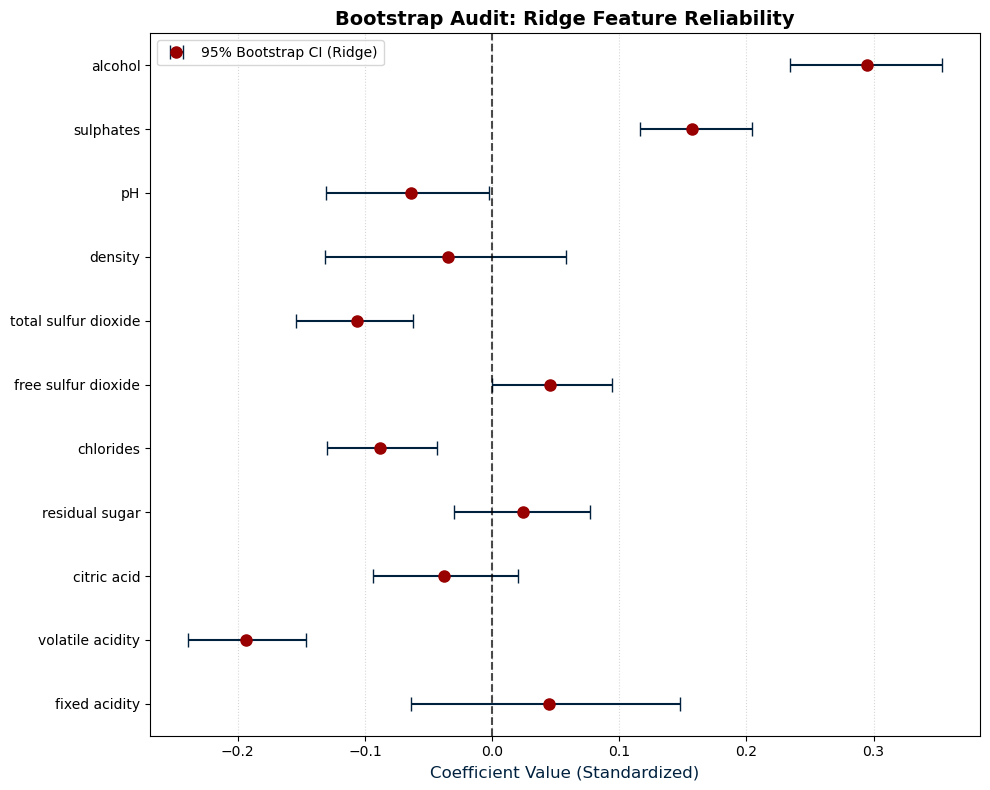


AUDITOR VERDICT (Ridge alpha=1.0):
Reject: fixed acidity        - Interval -0.064 to 0.148 crosses zero.
Trust:  volatile acidity     - Interval -0.239 to -0.146 is stable.
Reject: citric acid          - Interval -0.094 to 0.020 crosses zero.
Reject: residual sugar       - Interval -0.030 to 0.077 crosses zero.
Trust:  chlorides            - Interval -0.130 to -0.043 is stable.
Reject: free sulfur dioxide  - Interval -0.000 to 0.094 crosses zero.
Trust:  total sulfur dioxide - Interval -0.154 to -0.062 is stable.
Reject: density              - Interval -0.131 to 0.058 crosses zero.
Trust:  pH                   - Interval -0.131 to -0.003 is stable.
Trust:  sulphates            - Interval 0.116 to 0.204 is stable.
Trust:  alcohol              - Interval 0.234 to 0.354 is stable.

Scientific Note:
Unlike OLS, Ridge coefficients are shrunk toward zero.
The bootstrap confirms if a feature remains stable even under
regularization and data perturbation.


In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Feb 10 16:31:20 2026

@author: sned
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# DTU Colors
DTU_RED = '#990000'
DTU_NAVY = '#00213E'

def bootstrap_audit_solution():
    '''
    Full solution for quantifying feature reliability via Bootstrap using Ridge Regression.
    '''
    # Load Wine Quality data
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    try:
        df = pd.read_csv(url, sep=';')
    except:
        print('Error: Could not retrieve data. Ensure internet connection is active.')
        return

    feature_names = df.drop('quality', axis=1).columns.tolist()
    X = StandardScaler().fit_transform(df.drop('quality', axis=1).values)
    y = df['quality'].values

    # Parameters
    # We use alpha=1.0 as the 'audited' complexity setting (from Exercise 2.2)
    alpha_val = 1.0
    B = 1000 
    N, M = X.shape
    
    boot_betas = np.zeros((B, M))

    print(f'--- Starting Ridge Bootstrap Audit (B={B}, alpha={alpha_val}) ---')

    # Perform Resampling
    for b in range(B):
        # Resample with replacement to simulate new experiments
        X_resamp, y_resamp = resample(X, y, replace=True, n_samples=N, random_state=b)
        
        # Fit Ridge model on bootstrap sample
        model = Ridge(alpha=alpha_val).fit(X_resamp, y_resamp)
        boot_betas[b, :] = model.coef_

    # Calculate 95% Percentile Confidence Intervals
    lower_bounds = np.percentile(boot_betas, 2.5, axis=0)
    upper_bounds = np.percentile(boot_betas, 97.5, axis=0)
    means = np.mean(boot_betas, axis=0)

    # --- VISUALIZATION ---
    plt.figure(figsize=(10, 8))
    
    # Calculate error lengths for plt.errorbar
    errors = np.array([means - lower_bounds, upper_bounds - means])
    
    # Plotting horizontal bars with DTU branding
    plt.errorbar(means, range(M), xerr=errors, fmt='o', 
                 color=DTU_RED, ecolor=DTU_NAVY, capsize=5, 
                 markersize=8, label='95% Bootstrap CI (Ridge)')
    
    # Add a vertical line at zero (The Auditor's Threshold)
    plt.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    plt.yticks(range(M), feature_names)
    plt.xlabel('Coefficient Value (Standardized)', fontsize=12, color=DTU_NAVY)
    plt.title('Bootstrap Audit: Ridge Feature Reliability', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle=':', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- VERDICT ---
    print('\nAUDITOR VERDICT (Ridge alpha=1.0):')
    for i, name in enumerate(feature_names):
        if lower_bounds[i] <= 0 <= upper_bounds[i]:
            print(f'Reject: {name:20} - Interval {lower_bounds[i]:.3f} to {upper_bounds[i]:.3f} crosses zero.')
        else:
            print(f'Trust:  {name:20} - Interval {lower_bounds[i]:.3f} to {upper_bounds[i]:.3f} is stable.')

    print('\nScientific Note:')
    print('Unlike OLS, Ridge coefficients are shrunk toward zero.')
    print('The bootstrap confirms if a feature remains stable even under')
    print('regularization and data perturbation.')

if __name__ == '__main__':
    bootstrap_audit_solution()